# Supply Chain Analytics: Data Engineering, Predictive Modeling & Business Review
**Objective:** To ingest, clean, and analyze global supply chain data, extract executive-level KPIs, identify supplier concentration risks, and forecast demand to prevent critical part shortages.

In [2]:
# 1. IMPORTS & ENVIRONMENT SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# Suppress warnings for a clean presentation
warnings.filterwarnings('ignore')

# Set corporate-ready visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
pd.options.display.float_format = '{:,.2f}'.format

print("Environment successfully initialized.")

Environment successfully initialized.


### 1. Data Ingestion & Governance Audit
In a production environment, ensuring data integrity is the critical first step before any analysis. This pipeline ingests the relational supply chain tables, standardizes datetime formats, and conducts an automated quality audit to check for null values and duplicates.

In [5]:
# 2. DATA INGESTION & TYPE CASTING
file_path = 'Demo_Dataset_Masrur_SupplyChain_AnalyticsDemo.xlsx'

# Load relational sheets into DataFrames
df_parts = pd.read_excel(file_path, sheet_name='Parts_Master')
df_demand = pd.read_excel(file_path, sheet_name='Demand_Forecast')
df_inventory = pd.read_excel(file_path, sheet_name='Inventory_Coverage')
df_po = pd.read_excel(file_path, sheet_name='Purchase_Orders')
df_npi = pd.read_excel(file_path, sheet_name='NPI_Program_Tracker')
df_supplier = pd.read_excel(file_path, sheet_name='Supplier_Scorecard')

# Standardize DateTime formats across the pipeline
df_demand['Week'] = pd.to_datetime(df_demand['Week'])
for col in ['PO_Date', 'Need_By_Date', 'Expected_Date']:
    df_po[col] = pd.to_datetime(df_po[col])
for col in ['Planned_Date', 'Actual_Date']:
    df_npi[col] = pd.to_datetime(df_npi[col])

# DATA QUALITY & GOVERNANCE AUDIT
print("--- AUTOMATED DATA QUALITY AUDIT ---")
audit_metrics = {
    "PO Missing Values": df_po.isnull().sum().sum(),
    "Demand Missing Values": df_demand.isnull().sum().sum(),
    "NPI Duplicate Rows": df_npi.duplicated().sum()
}

for key, val in audit_metrics.items():
    print(f"{key}: {val}")

if sum(audit_metrics.values()) == 0:
    print("STATUS: Data integrity verified. Pipeline cleared for analysis.")
else:
    print("STATUS: Anomalies detected. Imputation workflow required.")

--- AUTOMATED DATA QUALITY AUDIT ---
PO Missing Values: 0
Demand Missing Values: 0
NPI Duplicate Rows: 0
STATUS: Data integrity verified. Pipeline cleared for analysis.


### 2. Executive Business Metrics (KPIs)
Extracting top-level metrics to drive the Quarterly Business Review (QBR). This focuses on macro-level financial risk, supplier reliability, and immediate inventory threats.

In [8]:
# 3. EXECUTIVE KPI EXTRACTION
# Financial Risk: Calculate Spend at Risk due to delayed Purchase Orders
total_spend = df_po['Total_Value_USD'].sum()
delayed_spend = df_po[df_po['Status'] == 'Delayed']['Total_Value_USD'].sum()
delayed_pct = (delayed_spend / total_spend) * 100

# Operational Risk: Identify critical stockouts
critical_inventory = df_inventory[df_inventory['Shortage_Risk'] == 'CRITICAL']

# Supplier Health: Global On-Time Delivery
avg_otd = df_supplier['On_Time_Delivery_Pct'].mean()

print(f"--- SUPPLY CHAIN HEALTH: EXECUTIVE SUMMARY ---")
print(f"Total PO Spend Monitored: ${total_spend:,.2f}")
print(f"Spend at Risk (Delayed POs): ${delayed_spend:,.2f} ({delayed_pct:.1f}%)")
print(f"Immediate Action Required: {len(critical_inventory)} Parts show 'CRITICAL' shortage risk.")
print(f"Global Supplier On-Time Delivery: {avg_otd:.1f}%")

--- SUPPLY CHAIN HEALTH: EXECUTIVE SUMMARY ---
Total PO Spend Monitored: $36,611,351.97
Spend at Risk (Delayed POs): $8,506,766.23 (23.2%)
Immediate Action Required: 8 Parts show 'CRITICAL' shortage risk.
Global Supplier On-Time Delivery: 85.6%


### 3. Exploratory Data Analysis: Supplier & Delivery Risk
Visualizing the distribution of supplier risk and identifying regional bottlenecks in the procurement pipeline.

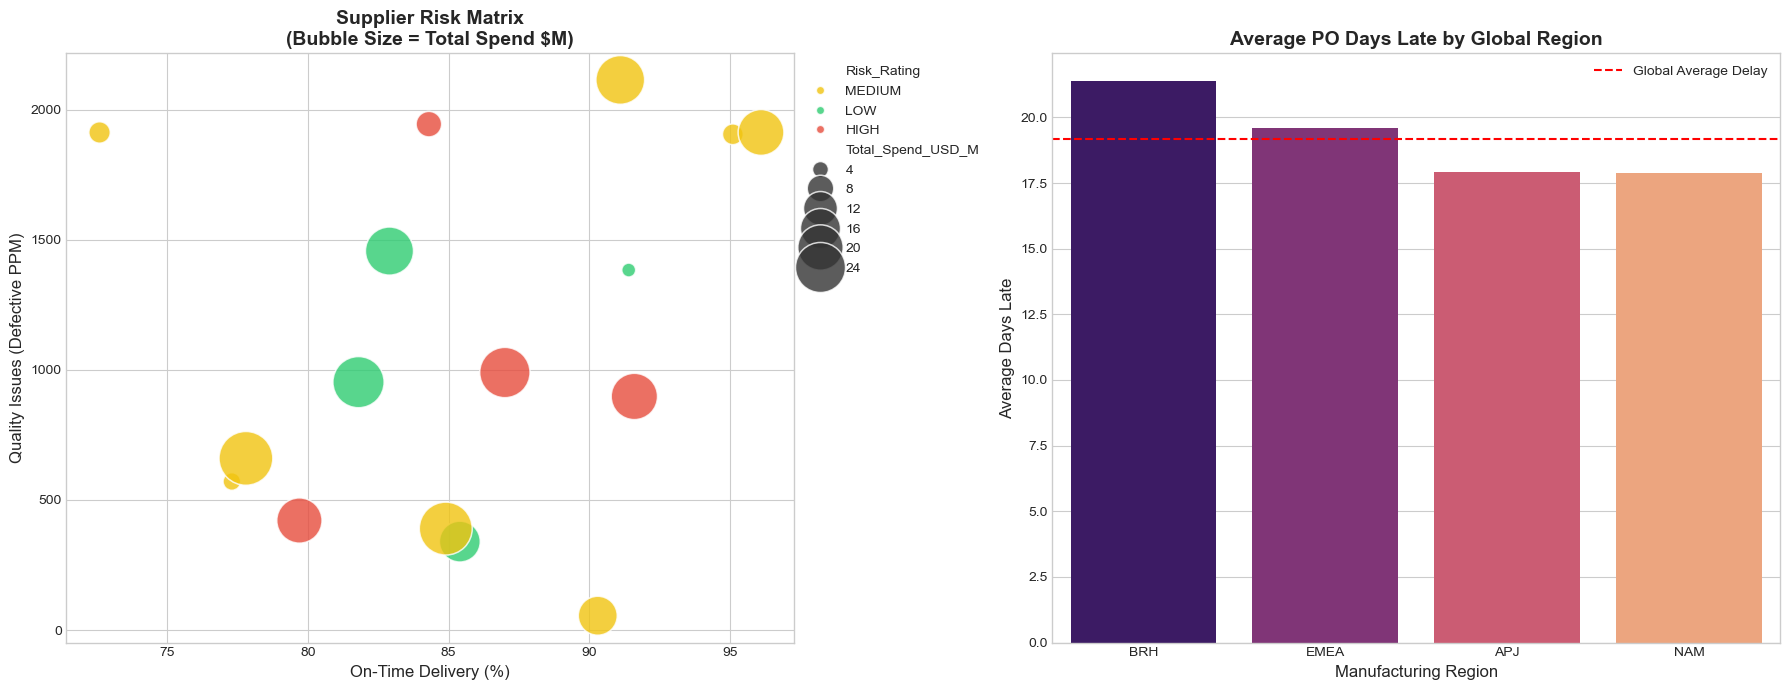

In [11]:
# 4. VISUALIZING RISK CONCENTRATION & DELAY TRENDS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Supplier Risk Matrix (Spend vs. Delivery vs. Quality)
sns.scatterplot(
    data=df_supplier, x='On_Time_Delivery_Pct', y='Quality_PPM', 
    size='Total_Spend_USD_M', hue='Risk_Rating', sizes=(100, 1500), 
    alpha=0.8, palette={'LOW': '#2ecc71', 'MEDIUM': '#f1c40f', 'HIGH': '#e74c3c'}, ax=ax1
)
ax1.set_title('Supplier Risk Matrix\n(Bubble Size = Total Spend $M)', fontsize=14, fontweight='bold')
ax1.set_xlabel('On-Time Delivery (%)', fontsize=12)
ax1.set_ylabel('Quality Issues (Defective PPM)', fontsize=12)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Plot 2: Purchase Order Delay Trends by Region
delayed_pos = df_po[df_po['Status'] == 'Delayed']
delay_by_region = delayed_pos.groupby('Region')['Days_Late'].mean().sort_values(ascending=False)

sns.barplot(x=delay_by_region.index, y=delay_by_region.values, palette='magma', ax=ax2)
ax2.set_title('Average PO Days Late by Global Region', fontsize=14, fontweight='bold')
ax2.set_xlabel('Manufacturing Region', fontsize=12)
ax2.set_ylabel('Average Days Late', fontsize=12)
ax2.axhline(y=delay_by_region.mean(), color='r', linestyle='--', label='Global Average Delay')
ax2.legend()

plt.tight_layout()
plt.show()

### 4. Predictive Modeling: Time-Series Demand Forecast
To transition from reactive reporting to proactive management, we apply an AI-driven Holt-Winters Exponential Smoothing model. This captures both underlying trends and supply chain seasonality to forecast aggregate global demand for the next 8 weeks. We then evaluate the model's performance against a validation holdout set.

Training Time-Series Model...
--- MODEL EVALUATION METRICS ---
Mean Absolute Error (MAE): 207.46 units
Root Mean Squared Error (RMSE): 239.60 units


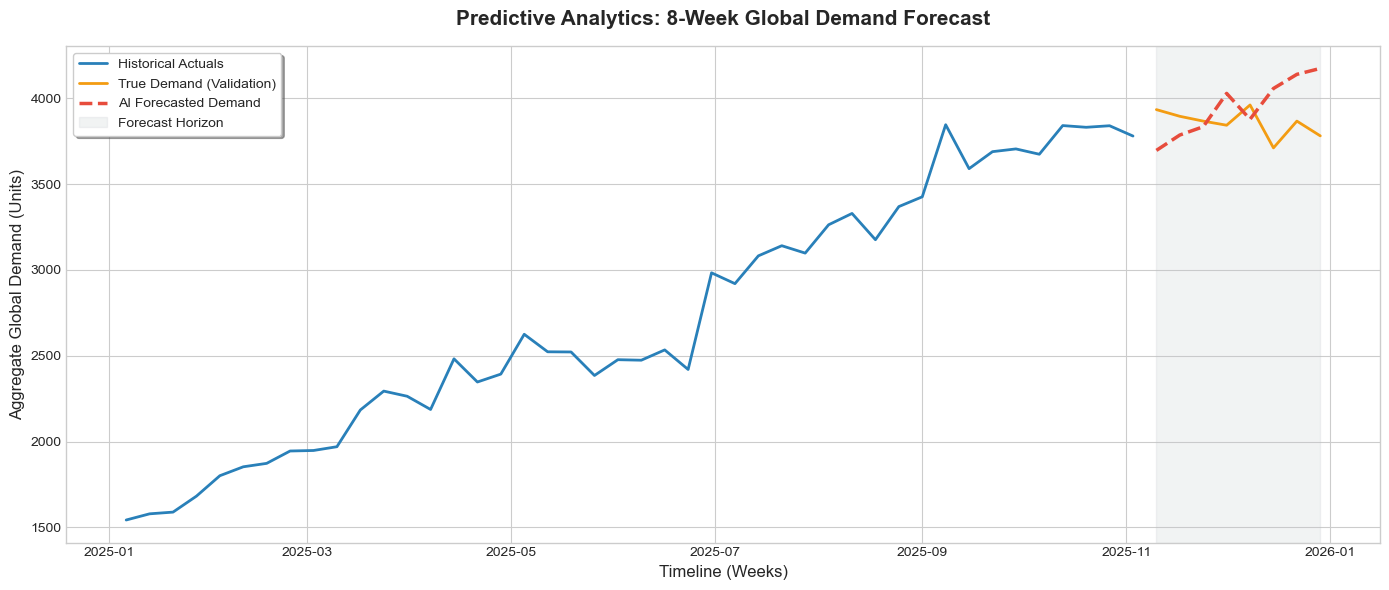

In [14]:
# 5. PREDICTIVE MODELING & ACCURACY EVALUATION
# Aggregate global demand by week and ensure strict weekly frequency
weekly_demand = df_demand.groupby('Week')['Actual_Demand'].sum().reset_index()
weekly_demand.set_index('Week', inplace=True)
weekly_demand = weekly_demand.asfreq('W-MON')

# Train/Test Split (Hold out the last 8 weeks for validation)
train = weekly_demand.iloc[:-8]
test = weekly_demand.iloc[-8:]

# Fit Holt-Winters Model
print("Training Time-Series Model...")
model = ExponentialSmoothing(
    train['Actual_Demand'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12
).fit()

# Generate forecasts for validation period
validation_predictions = model.forecast(steps=len(test))

# Evaluate Model Accuracy
mae = mean_absolute_error(test['Actual_Demand'], validation_predictions)
rmse = np.sqrt(mean_squared_error(test['Actual_Demand'], validation_predictions))

print("--- MODEL EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")

# Plot Forecast vs. Actuals
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['Actual_Demand'], label='Historical Actuals', linewidth=2, color='#2980b9')
plt.plot(test.index, test['Actual_Demand'], label='True Demand (Validation)', color='#f39c12', linewidth=2)
plt.plot(validation_predictions.index, validation_predictions, label='AI Forecasted Demand', color='#e74c3c', linestyle='--', linewidth=2.5)

# Highlight validation window
plt.axvspan(test.index[0], test.index[-1], color='#bdc3c7', alpha=0.2, label='Forecast Horizon')

plt.title('Predictive Analytics: 8-Week Global Demand Forecast', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Timeline (Weeks)', fontsize=12)
plt.ylabel('Aggregate Global Demand (Units)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()